## **Analisis Data Naive Bayes**

### 1. Deskripsi Data
Tahap awal dari proyek ini adalah memahami data yang akan kita olah. Dataset yang digunakan adalah **Diabetes Dataset**, yaitu dataset medis yang berisi informasi klinis pasien untuk menentukan apakah seseorang berisiko terkena diabetes atau tidak. Dataset ini sering digunakan dalam analisis klasifikasi karena memiliki parameter kesehatan yang relevan dan cukup lengkap.

Dataset ini terdiri dari berbagai fitur biologis yang dapat mempengaruhi kondisi diabetes seseorang, sehingga cocok digunakan untuk membangun model prediksi berbasis machine learning.

* Sumber Data: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
* Dataset ini berisi data pasien yang digunakan untuk memprediksi kemungkinan terkena diabetes berdasarkan kondisi medis.

Penelitian ini menggunakan dataset Diabetes untuk memprediksi apakah seorang pasien memiliki diabetes atau tidak berdasarkan data kesehatan yang dimiliki. Dataset ini terdiri dari **768 data pasien** dengan **8 fitur** dan **1 target class (Outcome)**.

**Fitur Dataset :**
| No | Fitur                     | Deskripsi Singkat                                      |
|----|--------------------------|--------------------------------------------------------|
| 1  | Pregnancies              | Jumlah kehamilan yang pernah dialami pasien           |
| 2  | Glucose                  | Kadar glukosa dalam darah                             |
| 3  | BloodPressure            | Tekanan darah diastolik (mm Hg)                       |
| 4  | SkinThickness            | Ketebalan lipatan kulit (mm)                          |
| 5  | Insulin                  | Kadar insulin dalam darah (mu U/ml)                   |
| 6  | BMI                      | Indeks Massa Tubuh (Body Mass Index)                  |
| 7  | DiabetesPedigreeFunction | Riwayat diabetes dalam keluarga (faktor keturunan)    |
| 8  | Age                      | Umur pasien (tahun)                                   |

**Target Class :**
| Target  | Keterangan            |
|---------|----------------------|
| 0       | Tidak diabetes       |
| 1       | Diabetes             |

Dataset ini termasuk data medis yang cukup kompleks karena mengandung berbagai parameter numerik yang saling berhubungan dalam menentukan kondisi kesehatan pasien.


### 2. Preprocessing Data
Tahap preprocessing data dilakukan untuk mempersiapkan dataset sebelum masuk ke proses pemodelan. Pada tahap ini, data dibersihkan, dipilih, dan diubah ke format yang sesuai agar dapat diproses dengan baik oleh algoritma machine learning.

Berikut adalah tahapan preprocessing yang dilakukan:

#### **a. CSV Reader**

Node CSV Reader digunakan untuk membaca dataset diabetes yang berbentuk file .csv. Data yang berhasil dibaca akan ditampilkan dalam bentuk tabel yang berisi seluruh fitur dan target class.

#### **b. Column Filter**

Node Column Filter digunakan untuk memilih kolom-kolom yang relevan saja. Kolom yang tidak diperlukan dapat dihapus agar model tidak memproses data yang tidak penting dan untuk meningkatkan efisiensi.

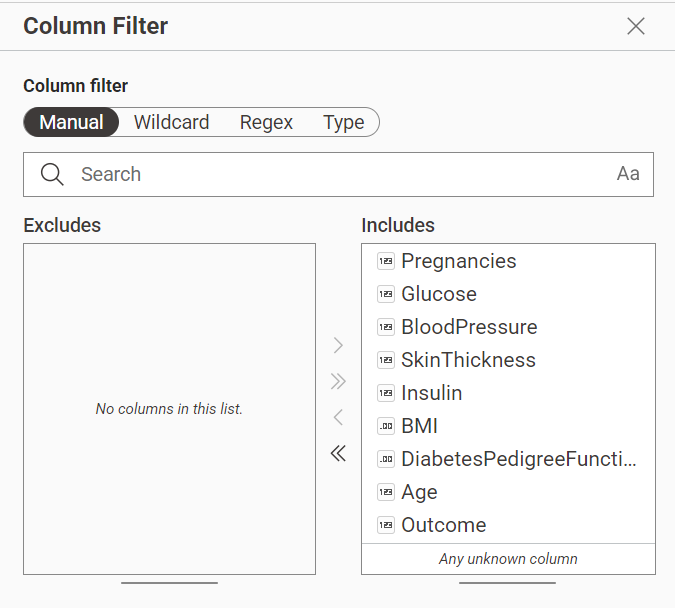

#### **c. Category to Number**

Node Category to Number berfungsi untuk mengubah data kategorikal menjadi data numerik. Hal ini penting karena algoritma machine learning umumnya hanya dapat memproses data dalam bentuk angka.

(Catatan: pada dataset diabetes ini sebenarnya semua fitur sudah numerik, jadi node ini bisa jadi tidak terlalu berpengaruh, tapi tetap aman digunakan.)

#### **d. Table Partitioner**

Node Table Partitioner digunakan untuk membagi dataset menjadi dua bagian:

Data Training → digunakan untuk melatih model
Data Testing → digunakan untuk menguji performa model

Pembagian ini penting agar model dapat dievaluasi secara objektif.

Datanya yaitu Proses Partisi Data (80:20)
* 80% Data Training (5.332 baris): Digunakan untuk melatih model agar memahami pola data.

* 20% Data Testing (1.334 baris): Digunakan untuk menguji keakuratan model dalam memprediksi data baru.

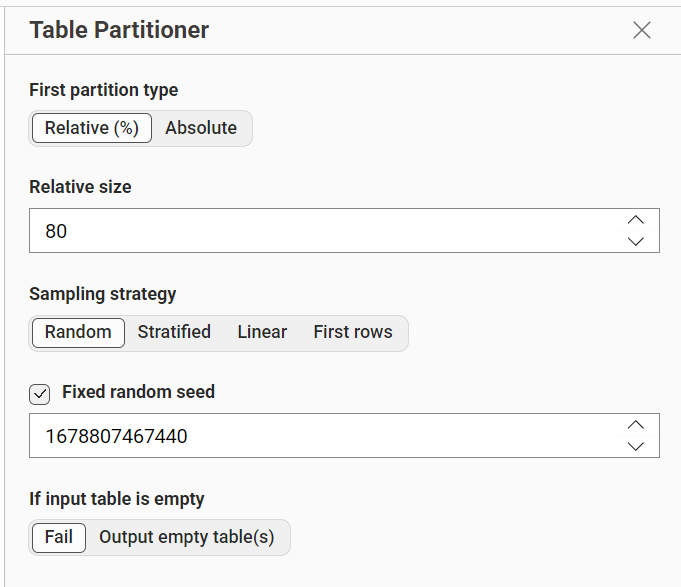

#### **e. Python Script**

Implementasi dilakukan menggunakan tools KNIME Analytics Platform dengan memanfaatkan library scikit-learn untuk perhitungan metode Naive Bayes, khususnya menggunakan algoritma Gaussian Naive Bayes.

Pada implementasi ini, data diambil dari satu input port KNIME yang berisi dataset (misalnya data diabetes), kemudian dilakukan proses training sekaligus prediksi menggunakan data yang sama.

* **Port 1 (Atas)** → 80% data (Training)
* **Port 2 (Bawah)** → 20% data (Testing)

**Script Pyhton**

In [ ]:
import knime.scripting.io as knio
import pandas as pd
from sklearn.naive_bayes import GaussianNB

# 1. Mengambil data dari input port
data = knio.input_tables[0].to_pandas()

# 2. Menentukan Target dan Fitur
# Di data diabetes, target biasanya 'Outcome'.
# Jika sebelumnya Anda pakai node 'Category to Number', pastikan namanya sesuai.
target_col = 'Outcome'

# Memisahkan fitur (X) dan label (y)
X = data.drop(columns=[target_col])
y = data[target_col]

# 3. Inisialisasi dan Melatih Model Naive Bayes
model = GaussianNB()
model.fit(X, y)

# 4. Membuat Prediksi
predictions = model.predict(X)

# 5. Menggabungkan hasil ke tabel output
output_df = data.copy()
output_df['Prediction'] = predictions

# 6. Mengirim kembali ke KNIME
knio.output_tables[0] = knio.Table.from_pandas(output_df)

#### **f. Hasil dan Evaluasi Model**

**Hasil Prediksi :**

Model digunakan untuk memprediksi apakah pasien memiliki diabetes atau tidak berdasarkan data yang diuji menggunakan algoritma Gaussian Naive Bayes dari library scikit-learn di KNIME Analytics Platform.

Hasil prediksi ditampilkan pada kolom “Prediction”, dengan keterangan:

* Nilai 1 → Pasien diprediksi mengidap diabetes
* Nilai 0 → Pasien diprediksi tidak mengidap diabetes

Kolom ini dapat dibandingkan dengan kolom “Outcome” (data sebenarnya) untuk melihat tingkat akurasi model dalam melakukan klasifikasi.

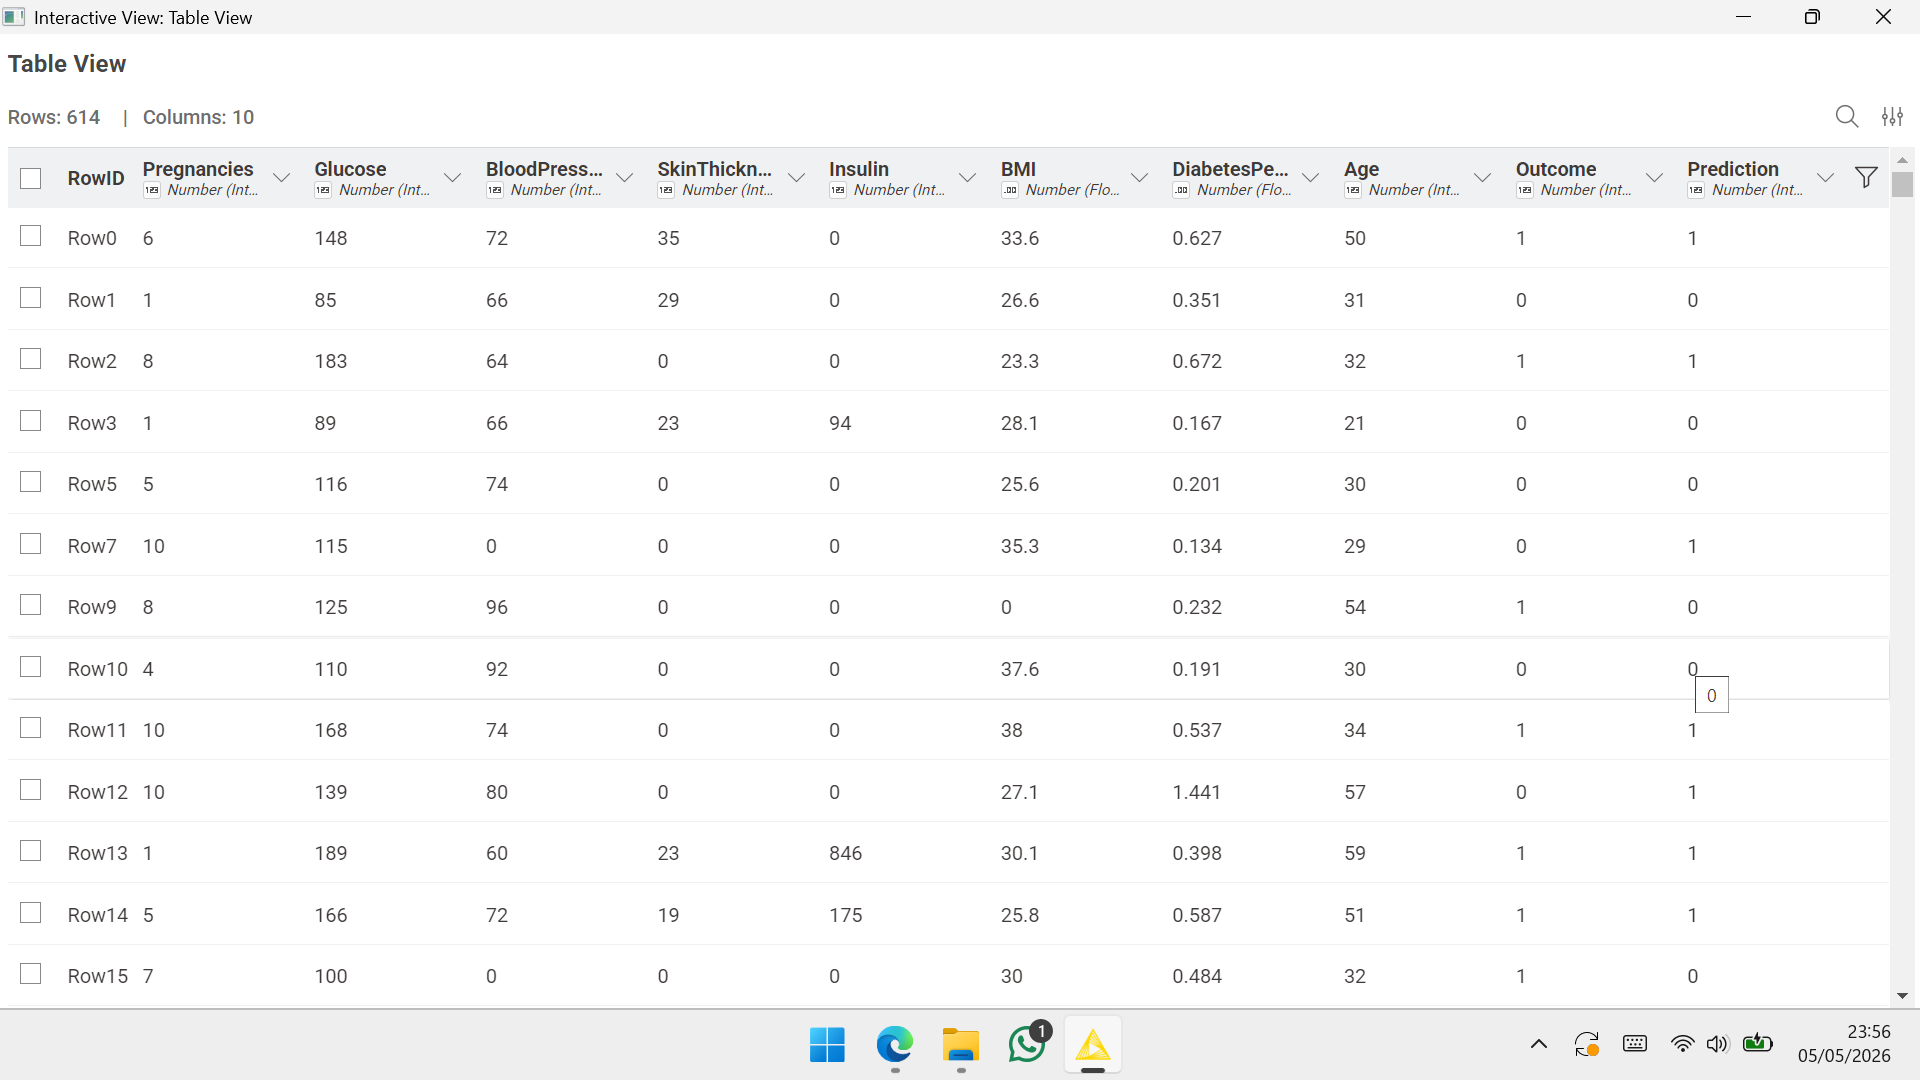






**Confusion Matrix**

Hasilnya:

* Nilai 1 Mengidap Diabetes = **222 orang**
* Nilai 0 Tidak Mengidap Diabetes = **392 orang**

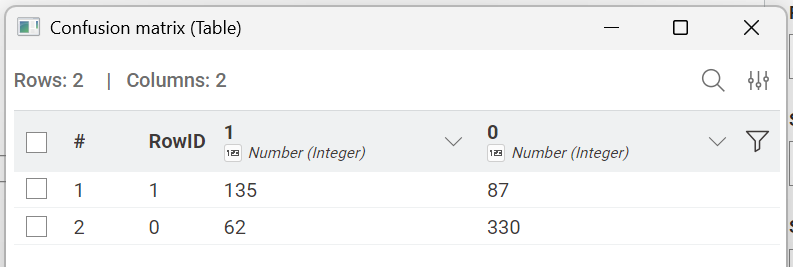

**Nilai akurasi dari prediction ini didapatkan :**


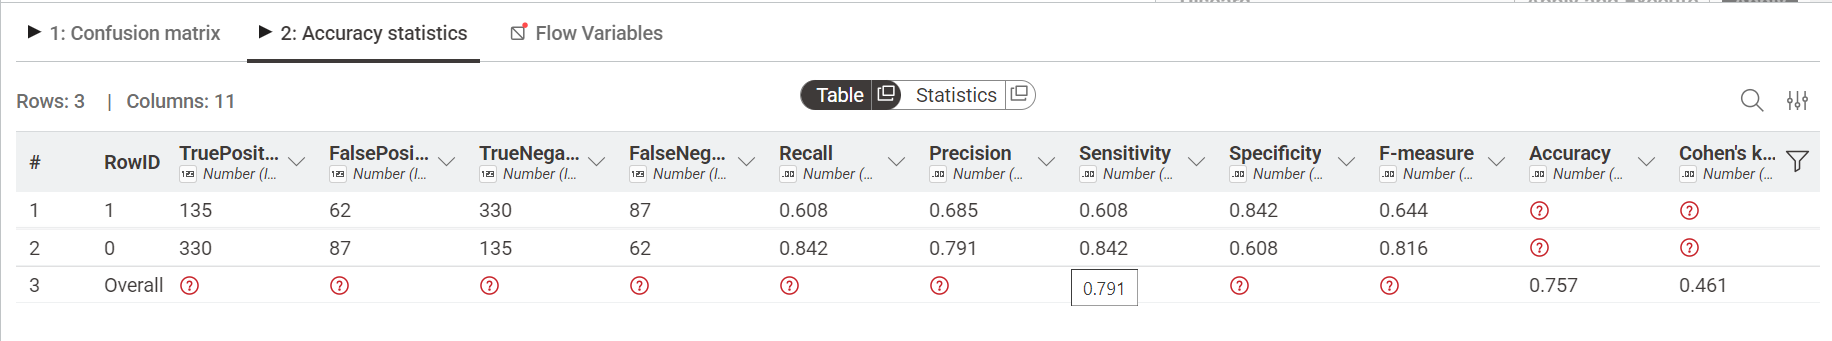

**Implementasi Knime**

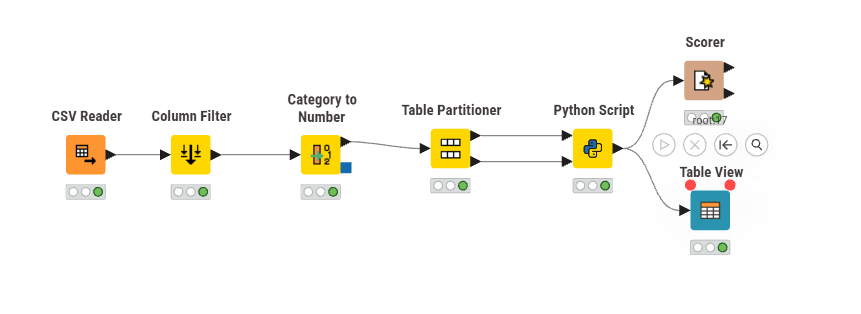


### 3. Kesimpulan Evaluasi Model

Model Naive Bayes berhasil memberikan hasil yang cukup baik dalam klasifikasi penyakit diabetes. Dengan tingkat akurasi yang stabil, model ini layak digunakan sebagai instrumen skrining atau alat bantu diagnosa awal dalam bidang medis untuk mengidentifikasi risiko diabetes pada pasien.

* Data Training: 5.332 pasien (80%)

* Data Testing: 1.334 pasien (20%)*

* Akurasi Model: 75,7% (Berdasarkan evaluasi Confusion Matrix)

* Hasil Diagnosa (Confusion Matrix):

    * True Positive (TP): 135 pasien diabetes berhasil diprediksi dengan benar.

    * True Negative (TN): 330 pasien sehat berhasil diprediksi dengan benar.


